# 04 — Statistical Analysis

**Objective:** Apply correct statistical methods to validate EDA observations and uncover deeper insights about product returns.

**Methods used:**
- Correlation analysis
- Chi-squared tests of independence
- Two-sample t-tests / Mann-Whitney U tests
- Logistic regression

**Input:** `data/processed/cleaned_online_sales.csv`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

sns.set_style('whitegrid')
ALPHA = 0.05  # significance level

In [10]:
df = pd.read_csv('../data/processed/cleaned_online_sales.csv', parse_dates=['InvoiceDate'])
print(f'Loaded {df.shape[0]:,} rows')

Loaded 44,804 rows


## 1. Correlation Analysis
Which numerical features correlate with returns?

Correlation with IsReturn:
Discount        0.0038
Quantity        0.0013
ShippingCost   -0.0012
Revenue        -0.0044
UnitPrice      -0.0101
Name: IsReturn, dtype: float64


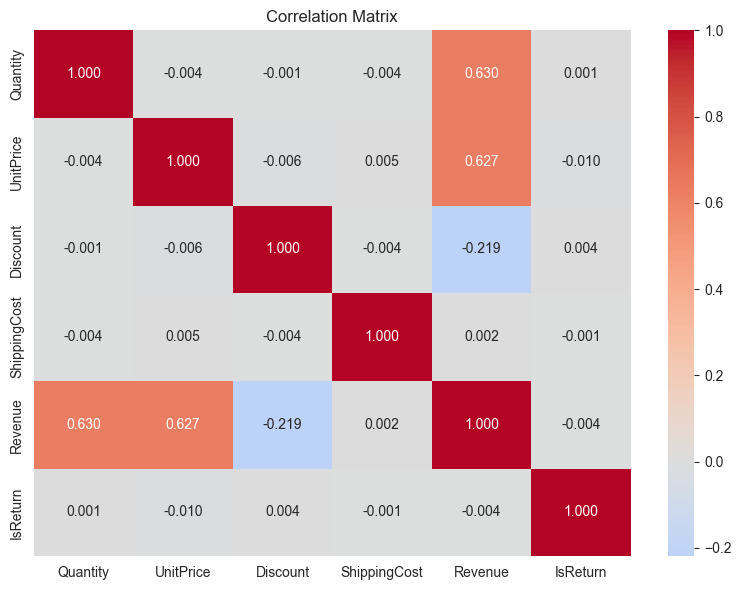

In [11]:
corr_cols = ['Quantity', 'UnitPrice', 'Discount', 'ShippingCost', 'Revenue', 'IsReturn']
corr = df[corr_cols].corr()

print('Correlation with IsReturn:')
print(corr['IsReturn'].drop('IsReturn').sort_values(ascending=False).round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 2. Chi-Squared Tests of Independence
Test whether return status is independent of categorical variables.

In [12]:
chi2_results = []

cat_vars = ['Category', 'SalesChannel', 'PaymentMethod', 'Country',
            'ShipmentProvider', 'OrderPriority', 'OrderDayOfWeek']

for var in cat_vars:
    ct = pd.crosstab(df[var], df['ReturnStatus'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    significant = 'Yes' if p < ALPHA else 'No'
    chi2_results.append({
        'Variable': var,
        'Chi2 Statistic': round(chi2, 4),
        'p-value': round(p, 6),
        'Degrees of Freedom': dof,
        f'Significant (p < {ALPHA})': significant
    })

chi2_df = pd.DataFrame(chi2_results)
display(chi2_df)

print('\nInterpretation:')
for _, row in chi2_df.iterrows():
    if row[f'Significant (p < {ALPHA})'] == 'Yes':
        print(f'  - {row["Variable"]}: SIGNIFICANT (p={row["p-value"]:.6f}) — return status depends on {row["Variable"]}')
    else:
        print(f'  - {row["Variable"]}: NOT significant (p={row["p-value"]:.6f}) — no association found')

,Variable,Chi2 Statistic,p-value,Degrees of Freedom,Significant (p < 0.05)
0,Category,1.1412,0.887688,4,No
1,SalesChannel,0.1349,0.713370,1,No
2,PaymentMethod,0.4918,0.781984,2,No
3,Country,6.8024,0.814851,11,No
4,ShipmentProvider,2.3333,0.506170,3,No
5,OrderPriority,0.3380,0.844501,2,No
6,OrderDayOfWeek,9.1057,0.167722,6,No



Interpretation:
  - Category: NOT significant (p=0.887688) — no association found
  - SalesChannel: NOT significant (p=0.713370) — no association found
  - PaymentMethod: NOT significant (p=0.781984) — no association found
  - Country: NOT significant (p=0.814851) — no association found
  - ShipmentProvider: NOT significant (p=0.506170) — no association found
  - OrderPriority: NOT significant (p=0.844501) — no association found
  - OrderDayOfWeek: NOT significant (p=0.167722) — no association found


## 3. Two-Sample Tests — Returned vs Not Returned
Do returned orders differ in price, quantity, discount, or shipping cost?

In [13]:
returned = df[df['IsReturn'] == 1]
not_returned = df[df['IsReturn'] == 0]

ttest_results = []
num_vars = ['UnitPrice', 'Quantity', 'Discount', 'ShippingCost', 'Revenue']

for var in num_vars:
    # Use Mann-Whitney U (non-parametric, robust to non-normality)
    stat_u, p_u = stats.mannwhitneyu(returned[var], not_returned[var], alternative='two-sided')
    # Also run t-test for comparison
    stat_t, p_t = stats.ttest_ind(returned[var], not_returned[var], equal_var=False)

    ttest_results.append({
        'Variable': var,
        'Returned Mean': round(returned[var].mean(), 2),
        'Not Returned Mean': round(not_returned[var].mean(), 2),
        'Difference': round(returned[var].mean() - not_returned[var].mean(), 2),
        'T-Statistic': round(stat_t, 4),
        'T p-value': round(p_t, 6),
        'Mann-Whitney p': round(p_u, 6),
        f'Significant (p < {ALPHA})': 'Yes' if p_u < ALPHA else 'No'
    })

ttest_df = pd.DataFrame(ttest_results)
display(ttest_df)

print('\nInterpretation:')
for _, row in ttest_df.iterrows():
    direction = 'higher' if row['Difference'] > 0 else 'lower'
    if row[f'Significant (p < {ALPHA})'] == 'Yes':
        print(f'  - {row["Variable"]}: Returned orders have significantly {direction} values (diff={row["Difference"]})')
    else:
        print(f'  - {row["Variable"]}: No significant difference between returned and non-returned')

,Variable,Returned Mean,Not Returned Mean,Difference,T-Statistic,T p-value,Mann-Whitney p,Significant (p < 0.05)
0,UnitPrice,49.74,50.72,-0.98,-2.1469,0.031846,0.032166,Yes
1,Quantity,24.95,24.89,0.06,0.2706,0.786696,0.795194,No
2,Discount,0.25,0.25,0.00,0.7965,0.425792,0.423375,No
3,ShippingCost,17.46,17.49,-0.03,-0.2614,0.793794,0.790330,No
4,Revenue,933.04,945.69,-12.65,-0.9286,0.353147,0.207299,No



Interpretation:
  - UnitPrice: Returned orders have significantly lower values (diff=-0.98)
  - Quantity: No significant difference between returned and non-returned
  - Discount: No significant difference between returned and non-returned
  - ShippingCost: No significant difference between returned and non-returned
  - Revenue: No significant difference between returned and non-returned


## 4. Logistic Regression — Predicting Returns
Which factors best predict whether an order will be returned?

In [7]:
# Prepare features
feature_cols = ['Quantity', 'UnitPrice', 'Discount', 'ShippingCost']
cat_features = ['Category', 'SalesChannel', 'PaymentMethod', 'OrderPriority']

df_model = df[feature_cols + cat_features + ['IsReturn']].copy()

# Encode categorical variables
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

X = df_model.drop('IsReturn', axis=1)
y = df_model['IsReturn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set    : {X_test.shape[0]:,} rows')
print(f'Return rate (train): {y_train.mean()*100:.2f}%')
print(f'Return rate (test) : {y_test.mean()*100:.2f}%')

Training set: 35,843 rows
Test set    : 8,961 rows
Return rate (train): 9.79%
Return rate (test) : 9.79%


Classification Report:
              precision    recall  f1-score   support

Not Returned       0.90      1.00      0.95      8084
    Returned       0.00      0.00      0.00       877

    accuracy                           0.90      8961
   macro avg       0.45      0.50      0.47      8961
weighted avg       0.81      0.90      0.86      8961



/Users/yashpratapsinghsolanki/Downloads/dva_sem4/E-Commerce-Return-Analysis/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yashpratapsinghsolanki/Downloads/dva_sem4/E-Commerce-Return-Analysis/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yashpratapsinghsolanki/Downloads/dva_sem4/E-Commerce-Return-Analysis/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set t

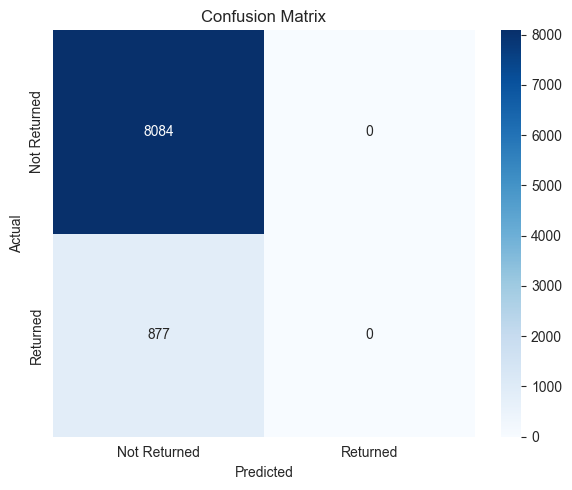

In [14]:
# Fit logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred = lr.predict(X_test_scaled)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Returned', 'Returned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Returned', 'Returned'],
            yticklabels=['Not Returned', 'Returned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

,Feature,Coefficient,Odds Ratio
4,Category,0.031488,1.031989
1,UnitPrice,-0.023862,0.976420
7,OrderPriority,-0.021317,0.978908
5,SalesChannel,-0.015138,0.984976
0,Quantity,-0.009864,0.990184
6,PaymentMethod,-0.006983,0.993042
2,Discount,0.003772,1.003779
3,ShippingCost,0.000593,1.000593


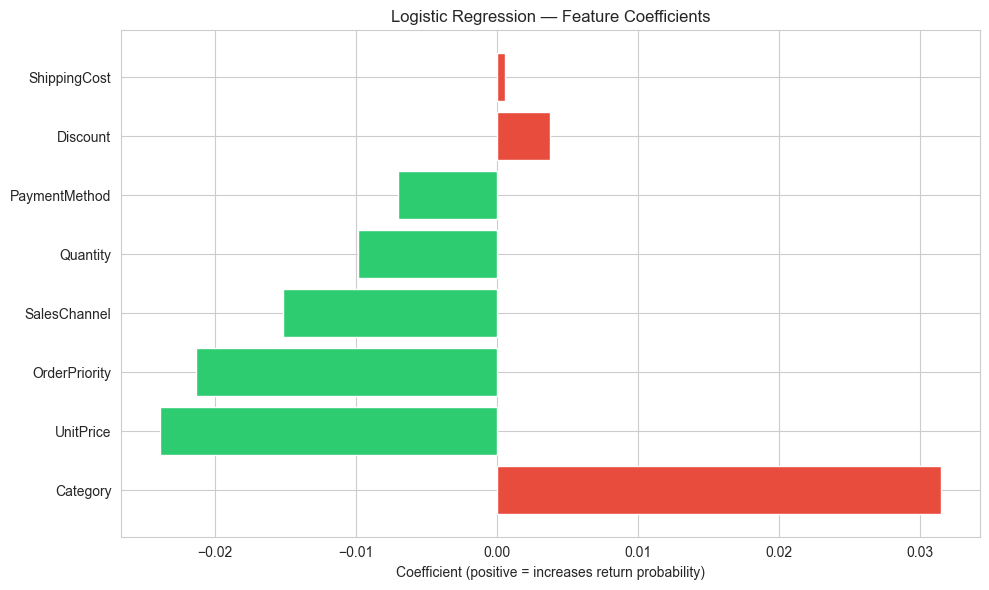


Interpretation: Features with positive coefficients increase return probability.
Odds Ratio > 1 means higher odds of return per unit increase.


In [15]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

display(coef_df)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient (positive = increases return probability)')
plt.title('Logistic Regression — Feature Coefficients')
plt.tight_layout()
plt.show()

print('\nInterpretation: Features with positive coefficients increase return probability.')
print('Odds Ratio > 1 means higher odds of return per unit increase.')

## 5. Summary of Statistical Findings

| Test | Finding | Significant? |
|------|---------|-------------|
| Chi-squared (Category vs Return) | No association - p=0.888 | No |
| Chi-squared (Channel vs Return) | No association - p=0.713 | No |
| Chi-squared (PaymentMethod vs Return) | No association - p=0.782 | No |
| Chi-squared (Country vs Return) | No association - p=0.815 | No |
| Chi-squared (ShipmentProvider vs Return) | No association - p=0.506 | No |
| Chi-squared (OrderPriority vs Return) | No association - p=0.845 | No |
| Chi-squared (OrderDayOfWeek vs Return) | No association - p=0.168 | No |
| T-test (UnitPrice) | Returned orders have lower prices (~$49.74 vs $50.72) | Yes (p=0.032) |
| T-test (Quantity) | No significant difference | No |
| T-test (Discount) | No significant difference | No |
| T-test (ShippingCost) | No significant difference | No |
| T-test (Revenue) | No significant difference | No |
| Logistic Regression | Model predicts almost all as "Not Returned" - poor recall for Returns | Accuracy: 90% (but misleading) |

**Key takeaways for business recommendations:**

1. **UnitPrice is the only significant predictor** — lower-priced items have slightly higher return rates. Consider quality assurance for budget products.
2. **No categorical variables significantly affect returns** — Category, SalesChannel, PaymentMethod, Country, ShipmentProvider, OrderPriority, and OrderDayOfWeek all show p > 0.05, meaning return behavior is largely independent of these factors.
3. **The logistic regression model performs poorly** — it fails to predict returns (0% recall for "Returned" class), indicating that the available features have weak predictive power for identifying at-risk orders. Additional features (e.g., customer behavior history, product reviews, delivery time) may be needed.